# 🚀 Workshop Day 1: Data Engineering — Turning Junk into Fuel
## Agentic RAG: From Zero to Hero

**เวลา:** 3 ชั่วโมง | **ระดับ:** ปริญญาตรี

---

### 🎯 เป้าหมายของวันนี้

เราจะเรียนรู้ **Data Engineering Pipeline** สำหรับ RAG ตั้งแต่ต้นจนจบ:

```
📄 เอกสารดิบ → 🔍 ตรวจ Duplicate → ✂️ Chunking → 📝 Markdown → 🔢 Embedding → 🗄️ VectorDB → 🔎 Retrieval
```

> **RAG (Retrieval-Augmented Generation)** คือเทคนิคที่ช่วยให้ LLM ตอบคำถามได้แม่นยำขึ้น
> โดยการ "ค้นหา" ข้อมูลที่เกี่ยวข้องมาให้ก่อนที่จะ "สร้าง" คำตอบ


### 🗺️ ภาพรวม Pipeline วันนี้

| Step | Section | Task |
|:----:|---------|------|
| 📁 | Input | Raw Documents (PDF, TXT, DOCX) |
| ⬇️ | 1.1 Deduplication | ตรวจไฟล์ซ้ำด้วย MD5 Hash |
| ⬇️ | 1.2 Chunking | ตัดข้อความเป็นส่วนย่อย |
| ⬇️ | 1.3-1.4 Markdown | แปลง PDF → Markdown (Gemini / Docling) |
| ⬇️ | 1.5 Embedding | แปลงข้อความ → Vector (multilingual-e5-large) |
| ⬇️ | 1.6 Hybrid Search | ผสม Dense + Sparse (BM25) |
| ⬇️ | 1.7 VectorDB | ติดตั้ง Qdrant |
| ⬇️ | 1.8 Indexing | Upsert vectors เข้า Qdrant |
| 🔎 | 1.9 Retrieval | ค้นหา vectors ที่คล้ายกับ query |

> 💡 วันนี้เราจะทำ **ทุกขั้นตอน** ตั้งแต่เตรียมข้อมูลจนถึงค้นหา — เป็นพื้นฐานของ RAG ทั้งหมด!

---
## 📦 Section 0: ติดตั้ง Dependencies

ติดตั้ง library ที่จำเป็นทั้งหมดสำหรับ workshop วันนี้

In [24]:
%%time
# ติดตั้ง libraries ทั้งหมด
import importlib.util, subprocess, sys

def _pip_install(pkg_spec, import_name=None):
    pkg = pkg_spec.split('>=')[0].split('<=')[0].split('==')[0].split('[')[0].strip()
    imp = import_name or {
        'google-genai': 'google.genai', 'google-adk': 'google.adk',
        'sentence-transformers': 'sentence_transformers', 'qdrant-client': 'qdrant_client',
        'langchain-text-splitters': 'langchain_text_splitters',
        'langchain-huggingface': 'langchain_huggingface',
        'scikit-learn': 'sklearn', 'pymupdf': 'fitz',
        'docling-ibm-models': 'docling_ibm_models',
    }.get(pkg, pkg.replace('-', '_'))
    try:
        spec = importlib.util.find_spec(imp)
    except ModuleNotFoundError:
        spec = None
    has_version_constraint = any(op in pkg_spec for op in ('>=', '<=', '==', '>', '<', '!='))
    if spec is not None and not has_version_constraint:
        print(f'  \u23ed\ufe0f  {pkg}: skipped')
        return
    print(f'  \U0001f4e6 {pkg}: installing...', end='', flush=True)
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg_spec],
                       capture_output=True, text=True)
    print(f'\r  \u2705 {pkg}: done' if r.returncode == 0 else f'\r  \u274c {pkg}: failed')
    if r.returncode != 0: print(r.stderr)

for _pkg in ['google-genai', 'docling>=2.31', 'docling-ibm-models>=3.4', 'sentence-transformers', 'qdrant-client', 'langchain-text-splitters', 'rank_bm25', 'pymupdf', 'pythainlp', 'scikit-learn', 'rich']:
    _pip_install(_pkg)

# ล้าง cache ของ docling-models เพื่อป้องกัน ONNX file mismatch
import shutil, os
cache_path = os.path.expanduser('~/.cache/huggingface/hub/models--ds4sd--docling-models')
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print('🗑️ ล้าง docling-models cache แล้ว')

print('✅ ติดตั้งเรียบร้อยแล้ว!')
print('⚠️ กรุณา Restart runtime: Runtime → Restart session → แล้ว Run ทุก cell ใหม่')

  ⏭️  google-genai: skipped
  ✅ docling: donetalling...
  ✅ docling-ibm-models: donetalling...
  ⏭️  sentence-transformers: skipped
  ⏭️  qdrant-client: skipped
  ⏭️  langchain-text-splitters: skipped
  ⏭️  rank_bm25: skipped
  ⏭️  pymupdf: skipped
  ⏭️  pythainlp: skipped
  ⏭️  scikit-learn: skipped
  ⏭️  rich: skipped
✅ ติดตั้งเรียบร้อยแล้ว!
⚠️ กรุณา Restart runtime: Runtime → Restart session → แล้ว Run ทุก cell ใหม่
CPU times: total: 15.6 ms
Wall time: 7.65 s


In [25]:
%%time
# Import libraries หลัก
import hashlib
import os
import json
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown

print('✅ Import สำเร็จ!')

✅ Import สำเร็จ!
CPU times: total: 0 ns
Wall time: 0 ns


### 📂 เตรียมข้อมูลตัวอย่าง

เราจะสร้างข้อมูลตัวอย่างภาษาไทยสำหรับใช้ตลอด workshop

In [26]:
%%time
# สร้างโฟลเดอร์สำหรับเก็บข้อมูล
os.makedirs('data', exist_ok=True)
os.makedirs('output', exist_ok=True)

# ข้อมูลตัวอย่าง: สรุป Case Study ด้าน AI ในประเทศไทย
sample_texts = {

    'case_kmitl.txt': '''กรณีศึกษา: AI ที่สถาบันพระจอมเกล้าเจ้าคุณทหารลาดกระบัง (KMITL)

คณะวิศวกรรมศาสตร์ KMITL พัฒนาระบบ AI สำหรับ Smart Campus
ใช้ IoT sensor รวมกับ Machine Learning วิเคราะห์การใช้พลังงานในอาคารเรียน
ผลการทดสอบพบว่าลดค่าไฟฟ้าได้ 25% และเพิ่มประสิทธิภาพการใช้ห้องเรียน

นอกจากนี้ สาขาวิศวกรรมสารสนเทศ ยังพัฒนาระบบ NLP ภาษาไทย
สำหรับวิเคราะห์ความคิดเห็นนักศึกษาจากแบบประเมิน
ใช้ Sentiment Analysis และ Topic Modeling จัดกลุ่มปัญหา
ช่วยปรับปรุงหลักสูตรได้ตรงจุดมากขึ้น

ล่าสุด KMITL นำ RAG มาสร้างระบบ AI Tutor
ช่วยตอบคำถามวิชาเรียนจากเอกสารประกอบการสอนกว่า 200 วิชา
นักศึกษาสามารถถามคำถามได้ตลอด 24 ชั่วโมง
ระบบค้นหาคำตอบจาก lecture notes, slides, และตำราเรียน
''',

    'case_healthcare.txt': '''กรณีศึกษา: AI ในการแพทย์ไทย

โรงพยาบาลศิริราชได้นำ AI มาใช้ในการวิเคราะห์ภาพถ่ายทางการแพทย์ (Medical Imaging)
เช่น การตรวจจับมะเร็งปอดจากภาพ X-ray ด้วย Deep Learning
ผลการทดสอบพบว่า AI มีความแม่นยำ 95% เทียบกับรังสีแพทย์ที่ 92%

นอกจากนี้ยังมีการใช้ NLP วิเคราะห์เวชระเบียนอิเล็กทรอนิกส์ (EMR)
เพื่อช่วยแพทย์สรุปประวัติผู้ป่วยและแนะนำการรักษาที่เหมาะสม
ลดเวลาการอ่านเวชระเบียนจาก 15 นาทีเหลือ 2 นาทีต่อเคส

ความท้าทาย: ข้อมูลทางการแพทย์ภาษาไทยมีจำนวนจำกัด
ต้องใช้เทคนิค Transfer Learning จากโมเดลภาษาอังกฤษ
และ Fine-tune ด้วยข้อมูลภาษาไทยเพิ่มเติม''',

    'case_banking.txt': '''กรณีศึกษา: AI ในธนาคารและการเงิน

ธนาคารกสิกรไทยได้พัฒนาระบบ Chatbot ชื่อ KBTG
ที่ใช้ Large Language Model (LLM) ร่วมกับ RAG
ในการตอบคำถามลูกค้าเกี่ยวกับผลิตภัณฑ์ทางการเงิน

ระบบ RAG ทำงานโดยการค้นหาข้อมูลจากฐานความรู้ภายใน
ซึ่งประกอบด้วยเอกสารผลิตภัณฑ์ เงื่อนไขบริการ และ FAQ
จากนั้น LLM จะสร้างคำตอบที่เป็นธรรมชาติจากข้อมูลที่ค้นพบ

ผลลัพธ์: ลดภาระ Call Center ได้ 40%
ความพึงพอใจลูกค้าเพิ่มขึ้น 25%
สามารถให้บริการ 24 ชั่วโมง โดยไม่ต้องรอพนักงาน

เทคโนโลยีที่ใช้: Vector Database สำหรับเก็บ Embedding
Hybrid Search ผสม Dense + Sparse เพื่อค้นหาข้อมูลที่ตรงกับคำถาม''',

    'case_banking_duplicate.txt': '''กรณีศึกษา: AI ในธนาคารและการเงิน

ธนาคารกสิกรไทยได้พัฒนาระบบ Chatbot ชื่อ KBTG
ที่ใช้ Large Language Model (LLM) ร่วมกับ RAG
ในการตอบคำถามลูกค้าเกี่ยวกับผลิตภัณฑ์ทางการเงิน

ระบบ RAG ทำงานโดยการค้นหาข้อมูลจากฐานความรู้ภายใน
ซึ่งประกอบด้วยเอกสารผลิตภัณฑ์ เงื่อนไขบริการ และ FAQ
จากนั้น LLM จะสร้างคำตอบที่เป็นธรรมชาติจากข้อมูลที่ค้นพบ

ผลลัพธ์: ลดภาระ Call Center ได้ 40%
ความพึงพอใจลูกค้าเพิ่มขึ้น 25%
สามารถให้บริการ 24 ชั่วโมง โดยไม่ต้องรอพนักงาน

เทคโนโลยีที่ใช้: Vector Database สำหรับเก็บ Embedding
Hybrid Search ผสม Dense + Sparse เพื่อค้นหาข้อมูลที่ตรงกับคำถาม''',

    'case_education.txt': '''กรณีศึกษา: AI ในการศึกษาไทย

มหาวิทยาลัยหลายแห่งในไทยเริ่มนำ AI มาช่วยในการเรียนการสอน
เช่น ระบบ Intelligent Tutoring System ที่ปรับเนื้อหาตามระดับของผู้เรียน

ตัวอย่างที่น่าสนใจคือการใช้ RAG สร้างระบบถาม-ตอบอัตโนมัติ
สำหรับวิชาเรียน โดยนำเอกสารประกอบการสอน Slides และหนังสือ
มา Embed เป็น Vector แล้วเก็บใน Vector Database

เมื่อนักศึกษาถามคำถาม ระบบจะค้นหาเนื้อหาที่เกี่ยวข้อง
แล้วใช้ LLM สร้างคำตอบพร้อมอ้างอิงแหล่งที่มา

ขั้นตอนสำคัญในการสร้างระบบนี้:
1. เตรียมข้อมูล: แปลง PDF เป็น Markdown
2. ตัดข้อความ: ใช้ Chunking แบ่งเนื้อหาเป็นส่วนย่อย
3. สร้าง Embedding: แปลง Chunk เป็น Vector ด้วยโมเดลที่รองรับภาษาไทย
4. จัดเก็บ: Upsert Vector เข้า Qdrant หรือ Vector DB อื่น
5. ค้นหา: ใช้ Hybrid Search ค้นหา Chunk ที่เกี่ยวข้อง
6. สร้างคำตอบ: ส่ง Context ให้ LLM สร้างคำตอบ

ผลลัพธ์: นักศึกษาสามารถเรียนรู้ด้วยตนเองได้ตลอด 24 ชั่วโมง
ลดภาระอาจารย์ในการตอบคำถามซ้ำๆ ได้กว่า 60%''',

    'case_agriculture.txt': '''กรณีศึกษา: AI ในการเกษตรอัจฉริยะ

Smart Farming ในประเทศไทยใช้ AI วิเคราะห์ภาพถ่ายดาวเทียม
และข้อมูลจาก IoT Sensor เพื่อพยากรณ์ผลผลิตและเฝ้าระวังโรคพืช

ระบบ Computer Vision สามารถตรวจจับโรคข้าวได้จากภาพถ่ายใบข้าว
โดยใช้ Convolutional Neural Network (CNN) ที่ Train ด้วยภาพถ่าย
โรคข้าวกว่า 50,000 ภาพ ครอบคลุม 8 โรคหลัก

นอกจากนี้ยังมีการใช้ NLP วิเคราะห์ข้อมูลราคาสินค้าเกษตร
จากข่าวสาร รายงานภาครัฐ และ Social Media
เพื่อช่วยเกษตรกรตัดสินใจเรื่องการปลูกและการขาย

ความท้าทายของ AI ในการเกษตรไทย:
- ข้อมูลกระจัดกระจายอยู่ในหลายหน่วยงาน
- ภาษาและศัพท์เฉพาะทางการเกษตรไทย
- ต้องทำ Data Engineering เพื่อรวมและทำความสะอาดข้อมูลก่อน'''
}

for fname, content in sample_texts.items():
    with open(f'data/{fname}', 'w', encoding='utf-8') as f:
        f.write(content)

print(f'✅ สร้างไฟล์ตัวอย่าง {len(sample_texts)} ไฟล์ ในโฟลเดอร์ data/')
print()
for fname in sorted(sample_texts.keys()):
    print(f'  📄 {fname}')

✅ สร้างไฟล์ตัวอย่าง 6 ไฟล์ ในโฟลเดอร์ data/

  📄 case_agriculture.txt
  📄 case_banking.txt
  📄 case_banking_duplicate.txt
  📄 case_education.txt
  📄 case_healthcare.txt
  📄 case_kmitl.txt
CPU times: total: 0 ns
Wall time: 3.01 ms


---
## 🔍 Section 1.1: ตรวจสอบ Duplicate ด้วย MD5

### MD5 Hash คืออะไร?

**MD5 (Message Digest Algorithm 5)** คืออัลกอริทึมที่แปลงข้อมูลใดๆ ให้เป็นค่า hash ขนาด 128-bit (32 ตัวอักษร hex)

- ข้อมูลเดียวกัน → ได้ hash เดียวกัน **เสมอ**
- ข้อมูลต่างกันแม้เพียงนิดเดียว → ได้ hash ต่างกัน **โดยสิ้นเชิง**

### ทำไมต้องเช็ค Duplicate?

ในงาน RAG ถ้ามีเอกสารซ้ำกัน:
- ❌ เปลือง storage และเวลา embedding
- ❌ ผลการค้นหาซ้ำซ้อน
- ❌ LLM อาจสับสนจากบริบทที่ซ้ำกัน

In [27]:
%%time
def compute_md5(filepath):
    """คำนวณ MD5 hash ของไฟล์"""
    md5_hash = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b''):
            md5_hash.update(chunk)
    return md5_hash.hexdigest()

# ทดสอบ: คำนวณ MD5 ของทุกไฟล์
print('📊 MD5 Hash ของแต่ละไฟล์:')
print('=' * 70)
file_hashes = {}
for fname in sorted(os.listdir('data')):
    fpath = f'data/{fname}'
    if os.path.isfile(fpath):
        h = compute_md5(fpath)
        file_hashes[fname] = h
        print(f'  {fname:<25} → {h}')

print('\n🔍 สังเกต: case_banking.txt และ case_banking_duplicate.txt มี hash เดียวกัน!')

📊 MD5 Hash ของแต่ละไฟล์:
  case_agriculture.txt      → a9a7a478c933f2806b91dbeb4c6ab59f
  case_banking.txt          → c83d6cac633aa257a3c3daae275d0000
  case_banking_duplicate.txt → c83d6cac633aa257a3c3daae275d0000
  case_education.txt        → 3c86e83af1857a116827b64c830702aa
  case_healthcare.txt       → e095b307c081b59fb2c7dcc98a6e15a1
  case_kmitl.txt            → 1c22e5d5133b155d24fcedc764acf5b4
  sample.pdf                → e9e61c4652a01dd7756eb3ef57001d81

🔍 สังเกต: case_banking.txt และ case_banking_duplicate.txt มี hash เดียวกัน!
CPU times: total: 0 ns
Wall time: 8.02 ms


In [28]:
%%time
def find_duplicates(directory):
    """ค้นหาไฟล์ที่ซ้ำกันในโฟลเดอร์โดยใช้ MD5"""
    hash_map = {}  # md5 → [list of filepaths]

    for fname in os.listdir(directory):
        fpath = os.path.join(directory, fname)
        if os.path.isfile(fpath):
            h = compute_md5(fpath)
            hash_map.setdefault(h, []).append(fname)

    # กรองเฉพาะกลุ่มที่มีมากกว่า 1 ไฟล์
    duplicates = {h: files for h, files in hash_map.items() if len(files) > 1}
    return duplicates, hash_map

duplicates, hash_map = find_duplicates('data')

if duplicates:
    print('⚠️ พบไฟล์ซ้ำกัน!')
    for h, files in duplicates.items():
        print(f'\n  Hash: {h}')
        print(f'  ไฟล์ที่ซ้ำกัน: {", ".join(files)}')
        print(f'  → เก็บไว้: {files[0]}, ลบออก: {", ".join(files[1:])}')
else:
    print('✅ ไม่พบไฟล์ซ้ำกัน')

⚠️ พบไฟล์ซ้ำกัน!

  Hash: c83d6cac633aa257a3c3daae275d0000
  ไฟล์ที่ซ้ำกัน: case_banking.txt, case_banking_duplicate.txt
  → เก็บไว้: case_banking.txt, ลบออก: case_banking_duplicate.txt
CPU times: total: 0 ns
Wall time: 2.51 ms


In [29]:
%%time
# ลบไฟล์ที่ซ้ำ (เก็บเฉพาะตัวแรก)
removed = []
for h, files in duplicates.items():
    for f in files[1:]:  # ลบทุกตัวยกเว้นตัวแรก
        os.remove(f'data/{f}')
        removed.append(f)

print(f'🗑️ ลบไฟล์ซ้ำแล้ว {len(removed)} ไฟล์: {", ".join(removed)}')
print(f'📁 ไฟล์ที่เหลือ: {sorted(os.listdir("data"))}')

🗑️ ลบไฟล์ซ้ำแล้ว 1 ไฟล์: case_banking_duplicate.txt
📁 ไฟล์ที่เหลือ: ['case_agriculture.txt', 'case_banking.txt', 'case_education.txt', 'case_healthcare.txt', 'case_kmitl.txt', 'sample.pdf']
CPU times: total: 0 ns
Wall time: 1.01 ms


### 💡 สังเกต
- `case_banking.txt` และ `case_banking_duplicate.txt` ได้ **hash เดียวกัน** → เนื้อหาเหมือนกัน 100%
- แม้ชื่อไฟล์ต่างกัน แต่ MD5 ดูที่ **เนื้อหา** ไม่ใช่ชื่อ
- ลบ duplicate → ลด storage + ป้องกันผลค้นหาซ้ำซ้อน

> 🎯 ในงานจริง อาจมีไฟล์ซ้ำหลายพัน — MD5 ช่วยจับได้ทันที

### 🧪 แบบฝึกหัด 1.1

ลองสร้างไฟล์เพิ่มอีก 2-3 ไฟล์ (มีบางไฟล์ซ้ำ) แล้วใช้ฟังก์ชัน `find_duplicates()` ตรวจสอบ

In [30]:
%%time
# 🧪 แบบฝึกหัด: สร้างไฟล์เพิ่มและทดสอบ duplicate detection

# 💡 Hint:
#   1. สร้างไฟล์ใหม่ด้วย open('data/my_file.txt', 'w')
#   2. ลองสร้างไฟล์ที่เนื้อหาซ้ำกัน
#   3. เรียก find_duplicates('data') ดูผล

# with open('data/test1.txt', 'w') as f:
#     f.write('เนื้อหาทดสอบ')
# with open('data/test2.txt', 'w') as f:
#     f.write('เนื้อหาทดสอบ')  # ซ้ำกัน!
# find_duplicates('data')

CPU times: total: 0 ns
Wall time: 0 ns


---
## ✂️ Section 1.2: Chunking แบบต่างๆ

### ทำไมต้อง Chunk?

- LLM มี **context window จำกัด** — ส่งเอกสาร 100 หน้าทั้งหมดไม่ได้
- Embedding model ทำงานได้ดีกับข้อความ **สั้นถึงปานกลาง** (ไม่เกิน 512 tokens)
- Chunk ที่เหมาะสมช่วยให้ **retrieval แม่นยำขึ้น**

### วิธีการ Chunk ที่เราจะเรียนรู้

| วิธี | หลักการ | ข้อดี | ข้อเสีย |
|------|---------|-------|--------|
| Fixed-size | ตัดตามจำนวนตัวอักษร | ง่าย, เร็ว | อาจตัดกลางประโยค |
| Recursive | แบ่งตาม separator ซ้อนกัน | ผลดีกว่า fixed | ต้องกำหนด separators |
| Sentence-based | ตัดตามประโยค | รักษาความหมาย | ขนาด chunk ไม่สม่ำเสมอ |
| Semantic | ใช้ embedding จับกลุ่ม | แม่นยำที่สุด | ช้า, ต้นทุนสูง |

In [31]:
%%time
# โหลดข้อความตัวอย่าง
all_docs = {}  # เก็บแต่ละเอกสารแยกกัน
all_text = ''

for fname in sorted(os.listdir('data')):
    fpath = f'data/{fname}'
    if os.path.isfile(fpath) and fname.endswith('.txt'):
        with open(fpath, 'r', encoding='utf-8') as f:
            content = f.read()
            all_docs[fname] = content
            all_text += '\n\n' + content

print(f'📄 จำนวนเอกสาร: {len(all_docs)} ไฟล์')
print(f'📄 ข้อความรวม: {len(all_text)} ตัวอักษร')
for fname, content in all_docs.items():
    print(f'  📄 {fname}: {len(content)} ตัวอักษร')

📄 จำนวนเอกสาร: 5 ไฟล์
📄 ข้อความรวม: 3284 ตัวอักษร
  📄 case_agriculture.txt: 629 ตัวอักษร
  📄 case_banking.txt: 567 ตัวอักษร
  📄 case_education.txt: 877 ตัวอักษร
  📄 case_healthcare.txt: 547 ตัวอักษร
  📄 case_kmitl.txt: 654 ตัวอักษร
CPU times: total: 0 ns
Wall time: 1.33 ms


### วิธีที่ 1: Fixed-size Chunking

In [32]:
%%time
def fixed_size_chunk(text, chunk_size=200, overlap=50):
    """ตัดข้อความตามจำนวนตัวอักษรที่กำหนด"""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start = end - overlap  # เลื่อนกลับมาซ้อนเพื่อไม่ให้ขาดบริบท
    return chunks

fixed_chunks = fixed_size_chunk(all_text, chunk_size=200, overlap=50)
print(f'📊 Fixed-size: ได้ {len(fixed_chunks)} chunks')
print(f'\n--- Chunk ที่ 1 ---')
print(fixed_chunks[0])
print(f'\n--- Chunk ที่ 2 ---')
print(fixed_chunks[1])

📊 Fixed-size: ได้ 22 chunks

--- Chunk ที่ 1 ---


กรณีศึกษา: AI ในการเกษตรอัจฉริยะ

Smart Farming ในประเทศไทยใช้ AI วิเคราะห์ภาพถ่ายดาวเทียม
และข้อมูลจาก IoT Sensor เพื่อพยากรณ์ผลผลิตและเฝ้าระวังโรคพืช

ระบบ Computer Vision สามารถตรวจจับโรคข้าวได้จ

--- Chunk ที่ 2 ---
พืช

ระบบ Computer Vision สามารถตรวจจับโรคข้าวได้จากภาพถ่ายใบข้าว
โดยใช้ Convolutional Neural Network (CNN) ที่ Train ด้วยภาพถ่าย
โรคข้าวกว่า 50,000 ภาพ ครอบคลุม 8 โรคหลัก

นอกจากนี้ยังมีการใช้ NLP วิ
CPU times: total: 0 ns
Wall time: 1.01 ms


### วิธีที่ 2: Recursive Character Chunking (LangChain)

วิธีนี้จะพยายาม **แบ่งด้วย separator ตัวแรกก่อน** ถ้า chunk ยังใหญ่เกินไป → ลองตัวถัดไป

```python
separators = ['\n\n', '\n', '。', r'\. ', ' ', '']
#              ①      ②    ③     ④    ⑤   ⑥
```

| ลำดับ | Separator | ความหมาย | ตัวอย่าง |
|:-----:|-----------|----------|----------|
| ① | `\n\n` | **บรรทัดว่าง** (ย่อหน้าใหม่) | แบ่งระหว่างย่อหน้า |
| ② | `\n` | **ขึ้นบรรทัดใหม่** | แบ่งทีละบรรทัด |
| ③ | `。` | **มหัพภาค (จุดจีน/ญี่ปุ่น)** | จบประโยคภาษา CJK |
| ④ | `\. ` | **จุดภาษาอังกฤษ + เว้นวรรค** | "Hello. World" → ตัดตรงจุด |
| ⑤ | ` ` | **เว้นวรรค** | แบ่งทีละคำ |
| ⑥ | `''` | **ทุกตัวอักษร** (ทางเลือกสุดท้าย) | ตัดตรงกลางคำ |

**หลักการทำงาน:**
```
ข้อความยาวมาก → ลองตัดด้วย \n\n ก่อน
                  ↓ ถ้า chunk ยังยาว
                  ลองตัดด้วย \n
                  ↓ ถ้ายังยาว
                  ลองตัดด้วย จุด
                  ↓ ...
                  ตัดทีละตัวอักษร (สุดท้าย)
```

> 💡 **สำหรับภาษาไทย**: ไม่มีเว้นวรรคระหว่างคำ ดังนั้น separator ` ` จะไม่ค่อยมีผล
> การแบ่งด้วย `\n\n` และ `\n` จะเป็นตัวหลัก

In [33]:
%%time
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50,
    separators=['\n\n', '\n', '。', r'\. ', ' ', ''],  # ลำดับการแบ่ง
)

recursive_chunks = recursive_splitter.split_text(all_text)
print(f'📊 Recursive: ได้ {len(recursive_chunks)} chunks')
print(f'\n--- Chunk ที่ 1 ---')
print(recursive_chunks[0])
print(f'\n--- Chunk ที่ 2 ---')
print(recursive_chunks[1])

📊 Recursive: ได้ 21 chunks

--- Chunk ที่ 1 ---
กรณีศึกษา: AI ในการเกษตรอัจฉริยะ

Smart Farming ในประเทศไทยใช้ AI วิเคราะห์ภาพถ่ายดาวเทียม
และข้อมูลจาก IoT Sensor เพื่อพยากรณ์ผลผลิตและเฝ้าระวังโรคพืช

--- Chunk ที่ 2 ---
ระบบ Computer Vision สามารถตรวจจับโรคข้าวได้จากภาพถ่ายใบข้าว
โดยใช้ Convolutional Neural Network (CNN) ที่ Train ด้วยภาพถ่าย
โรคข้าวกว่า 50,000 ภาพ ครอบคลุม 8 โรคหลัก
CPU times: total: 0 ns
Wall time: 0 ns


### วิธีที่ 3: Sentence-based Chunking

In [34]:
%%time
import re

def sentence_chunk(text, max_sentences=3):
    """ตัดข้อความตามประโยค/บรรทัด (เหมาะกับภาษาไทย)"""
    # ภาษาไทยใช้ newline เป็นตัวแบ่งประโยคหลัก
    sentences = re.split(r'\n+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    for i in range(0, len(sentences), max_sentences):
        chunk = '\n'.join(sentences[i:i+max_sentences])
        if chunk:
            chunks.append(chunk)
    return chunks

sentence_chunks = sentence_chunk(all_text, max_sentences=3)
print(f'📊 Sentence-based: ได้ {len(sentence_chunks)} chunks')

# แสดง 3 chunks แรก
for idx in range(min(3, len(sentence_chunks))):
    print(f'\n--- Chunk ที่ {idx+1} ({len(sentence_chunks[idx])} ตัวอักษร) ---')
    print(sentence_chunks[idx])

📊 Sentence-based: ได้ 22 chunks

--- Chunk ที่ 1 (150 ตัวอักษร) ---
กรณีศึกษา: AI ในการเกษตรอัจฉริยะ
Smart Farming ในประเทศไทยใช้ AI วิเคราะห์ภาพถ่ายดาวเทียม
และข้อมูลจาก IoT Sensor เพื่อพยากรณ์ผลผลิตและเฝ้าระวังโรคพืช

--- Chunk ที่ 2 (166 ตัวอักษร) ---
ระบบ Computer Vision สามารถตรวจจับโรคข้าวได้จากภาพถ่ายใบข้าว
โดยใช้ Convolutional Neural Network (CNN) ที่ Train ด้วยภาพถ่าย
โรคข้าวกว่า 50,000 ภาพ ครอบคลุม 8 โรคหลัก

--- Chunk ที่ 3 (143 ตัวอักษร) ---
นอกจากนี้ยังมีการใช้ NLP วิเคราะห์ข้อมูลราคาสินค้าเกษตร
จากข่าวสาร รายงานภาครัฐ และ Social Media
เพื่อช่วยเกษตรกรตัดสินใจเรื่องการปลูกและการขาย
CPU times: total: 0 ns
Wall time: 0 ns


### 📊 เปรียบเทียบผลลัพธ์

In [35]:
%%time
print('📊 เปรียบเทียบจำนวน Chunks:')
print(f'  Fixed-size (200 chars):     {len(fixed_chunks)} chunks')
print(f'  Recursive (200 chars):      {len(recursive_chunks)} chunks')
print(f'  Sentence-based (3 sent):    {len(sentence_chunks)} chunks')

print('\n📏 ขนาดเฉลี่ยของ Chunk:')
for name, chunks in [('Fixed', fixed_chunks), ('Recursive', recursive_chunks), ('Sentence', sentence_chunks)]:
    sizes = [len(c) for c in chunks]
    print(f'  {name:<12}: avg={np.mean(sizes):.0f}, min={min(sizes)}, max={max(sizes)} ตัวอักษร')

📊 เปรียบเทียบจำนวน Chunks:
  Fixed-size (200 chars):     22 chunks
  Recursive (200 chars):      21 chunks
  Sentence-based (3 sent):    22 chunks

📏 ขนาดเฉลี่ยของ Chunk:
  Fixed       : avg=197, min=134, max=200 ตัวอักษร
  Recursive   : avg=157, min=62, max=198 ตัวอักษร
  Sentence    : avg=147, min=53, max=197 ตัวอักษร
CPU times: total: 0 ns
Wall time: 0 ns


### 💡 สังเกต
- **Fixed-size** ตัดกลางประโยค → ข้อมูลขาดหาย บริบทเสีย
- **Recursive** พยายามตัดตามย่อหน้า/ประโยค → ดีกว่า Fixed
- **Sentence-based** รักษาประโยคสมบูรณ์ แต่ขนาด chunk ไม่สม่ำเสมอ
- **overlap** ช่วยไม่ให้ข้อมูลหายตรงรอยต่อ

> 🎯 สำหรับภาษาไทย: **Recursive** เป็นตัวเลือกที่ดีที่สุดในแง่ คุณภาพ/ความเร็ว

### 🧪 แบบฝึกหัด 1.2

ลองปรับค่า `chunk_size` และ `overlap` แล้วเปรียบเทียบผลลัพธ์ ค่าไหนเหมาะกับข้อความภาษาไทยมากที่สุด?

In [36]:
%%time
# 🧪 แบบฝึกหัด: ทดลองปรับค่า chunk_size และ overlap

# 💡 Hint:
#   1. chunk_size=100 vs 500 → ได้ chunks ต่างกันกี่อัน?
#   2. overlap=0 vs 100 → ข้อความตรงรอยต่อหายมั้ย?

# for size in [100, 200, 500]:
#     chunks = fixed_size_chunk(all_text, chunk_size=size, overlap=50)
#     print(f'chunk_size={size}: {len(chunks)} chunks')

CPU times: total: 0 ns
Wall time: 0 ns


---
## 🤖 Section 1.3: แปลงเอกสารเป็น Markdown ด้วย Gemini

### Gemini Multimodal คืออะไร?

**Multimodal** = เข้าใจได้ทั้ง ข้อความ + รูป + PDF + video

```
อัปโหลด PDF → Gemini "มองเห็น" หน้ากระดาษ
    ↓
เข้าใจ layout: header, ตาราง, bullet, รูปภาพ
    ↓
แปลงเป็น Markdown ที่มีโครงสร้าง
```

### ข้อดี vs ข้อเสีย

| | ข้อดี | ข้อเสีย |
|---|------|--------|
| ✅ | เข้าใจ layout ซับซ้อน | ต้องมี internet |
| ✅ | รองรับภาษาไทย | เสีย API credits |
| ✅ | จัดการตาราง/รูปภาพได้ | ข้อมูลถูกส่งขึ้น cloud |

> ⚠️ **เอกสารลับ** (ข้อมูลผู้ป่วย, สัญญา) → พิจารณาใช้ Docling แทน (Section 1.4)

In [37]:
%%time
# ตั้งค่า Gemini API
# 🔑 ไปสร้าง API Key ได้ที่: https://aistudio.google.com/apikey
#
# วิธีตั้งค่า Colab Secrets:
#   1. คลิกไอคอน 🔑 ที่ sidebar ด้านซ้าย
#   2. กด 'Add new secret'
#   3. ตั้งชื่อ: GOOGLE_API_KEY
#   4. วาง API Key ที่ copy มา
#   5. เปิด toggle 'Notebook access'

try:
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    print('✅ โหลด API Key จาก Colab Secrets สำเร็จ!')
except Exception:
    GOOGLE_API_KEY = input('🔑 กรุณาวาง Gemini API Key ของคุณ: ')

from google import genai
client = genai.Client(api_key=GOOGLE_API_KEY)

# ทดสอบว่า API ใช้งานได้
response = client.models.generate_content(
    # model='gemini-2.5-flash',
    model='gemini-3.1-flash-lite',
    contents='ตอบว่า สวัสดี เท่านั้น'
)
print(f'✅ ทดสอบ Gemini API สำเร็จ: {response.text.strip()}')

✅ ทดสอบ Gemini API สำเร็จ: สวัสดี
CPU times: total: 31.2 ms
Wall time: 9.08 s


### สร้าง Sample PDF สำหรับทดสอบ

เราจะสร้าง PDF ตัวอย่างจากข้อความภาษาไทย

In [38]:
%%time
import fitz  # PyMuPDF
import subprocess

# ติดตั้ง Thai font บน Colab
# subprocess.run(['apt-get', 'install', '-y', '-qq', 'fonts-thai-tlwg'],
#                capture_output=True)
# print('✅ ติดตั้ง Thai font สำเร็จ')

# หา path ของ font ภาษาไทย
import platform
import glob

if platform.system() == "Linux":
    thai_fonts = glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf')
else:
    thai_fonts = glob.glob(r'C:\Windows\Fonts\*.ttf')

print(thai_fonts[:5])

THAI_FONT = thai_fonts[0] if thai_fonts else None

print(f'📝 ใช้ font: {THAI_FONT}')

def create_sample_pdf(filepath, text, title='เอกสารตัวอย่าง'):
    """สร้าง PDF จากข้อความภาษาไทย"""
    doc = fitz.open()
    page = doc.new_page()

    # โหลด font ภาษาไทย
    thai_font = fitz.Font(fontfile=THAI_FONT)

    # เขียนหัวข้อ
    tw = fitz.TextWriter(page.rect)
    y = 50
    tw.append((50, y), title, font=thai_font, fontsize=18)
    y += 40

    # เขียนเนื้อหาทีละบรรทัด
    for line in text.split('\n'):
        if y > 750:  # ขึ้นหน้าใหม่
            tw.write_text(page)
            page = doc.new_page()
            tw = fitz.TextWriter(page.rect)
            y = 50
        tw.append((50, y), line, font=thai_font, fontsize=11)
        y += 18

    tw.write_text(page)
    doc.save(filepath)
    doc.close()

# อ่านข้อความมาสร้าง PDF
with open('data/case_healthcare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

create_sample_pdf('data/sample.pdf', text, 'กรณีศึกษา: AI ในการแพทย์ไทย')
print('✅ สร้าง sample.pdf สำเร็จ (รองรับภาษาไทย!)')

['C:\\Windows\\Fonts\\AGENCYB.TTF', 'C:\\Windows\\Fonts\\AGENCYR.TTF', 'C:\\Windows\\Fonts\\ALGER.TTF', 'C:\\Windows\\Fonts\\ANTQUAB.TTF', 'C:\\Windows\\Fonts\\ANTQUABI.TTF']
📝 ใช้ font: C:\Windows\Fonts\AGENCYB.TTF
✅ สร้าง sample.pdf สำเร็จ (รองรับภาษาไทย!)
CPU times: total: 15.6 ms
Wall time: 6.11 ms


In [39]:
%%time
# ใช้ Gemini แปลง PDF เป็น Markdown
try:
    # ใช้ Gemini แปลง PDF เป็น Markdown
    import pathlib

    def pdf_to_markdown_gemini(pdf_path, client):
        """ใช้ Gemini อ่าน PDF แล้วแปลงเป็น Markdown"""
        # อ่านไฟล์ PDF
        pdf_bytes = pathlib.Path(pdf_path).read_bytes()

        prompt = '''อ่านเอกสาร PDF นี้แล้วแปลงเนื้อหาทั้งหมดเป็น Markdown format
    กฎ:
    - รักษาโครงสร้างเดิม (หัวข้อ, ย่อหน้า, ตาราง)
    - ใช้ heading (#, ##, ###) ตามลำดับความสำคัญ
    - ถ้ามีตาราง ให้แปลงเป็น Markdown table
    - ถ้ามีรายการ ให้ใช้ bullet points
    - เก็บเนื้อหาครบถ้วน ห้ามสรุปหรือตัดทอน'''

        response = client.models.generate_content(
            # model='gemini-2.5-flash',
            model='gemini-3.1-flash-lite',
            contents=[
                genai.types.Part.from_bytes(data=pdf_bytes, mime_type='application/pdf'),
                prompt
            ]
        )
        return response.text

    # ทดสอบ
    markdown_output = pdf_to_markdown_gemini('data/sample.pdf', client)
    print('📝 ผลลัพธ์ Markdown จาก Gemini:')
    print('=' * 60)
    display(Markdown(markdown_output))
except Exception as e:
    print(f'❌ Error: {e}')
    print('💡 ลองตรวจสอบ: 1) API Key ถูกต้อง  2) Internet เชื่อมต่อ  3) ไฟล์ PDF ถูกต้อง')


📝 ผลลัพธ์ Markdown จาก Gemini:


# กรณีศึกษา: AI ในการแพทย์ไทย

กรณีศึกษา: AI ในการแพทย์ไทย

โรงพยาบาลศิริราชได้นำ AI มาใช้ในการวิเคราะห์ภาพถ่ายทางการแพทย์ (Medical Imaging) เช่น การตรวจจับมะเร็งปอดจากภาพ X-ray ด้วย Deep Learning ผลการทดสอบพบว่า AI มีความแม่นยำ 95% เทียบกับรังสีแพทย์ที่ 92%

นอกจากนี้ยังมีการใช้ NLP วิเคราะห์เวชระเบียนอิเล็กทรอนิกส์ (EMR) เพื่อช่วยแพทย์สรุปประวัติผู้ป่วยและแนะนำการรักษาที่เหมาะสม ลดเวลาการอ่านเวชระเบียนจาก 15 นาทีเหลือ 2 นาทีต่อเคส

ความท้าทาย: ข้อมูลทางการแพทย์ภาษาไทยมีจำนวนจำกัด ต้องใช้เทคนิค Transfer Learning จากโมเดลภาษาอังกฤษ และ Fine-tune ด้วยข้อมูลภาษาไทยเพิ่มเติม

CPU times: total: 15.6 ms
Wall time: 6.42 s


In [40]:
%%time
# บันทึกผลลัพธ์
with open('output/gemini_output.md', 'w', encoding='utf-8') as f:
    f.write(markdown_output)
print('✅ บันทึกผลลัพธ์ไว้ที่ output/gemini_output.md')

✅ บันทึกผลลัพธ์ไว้ที่ output/gemini_output.md
CPU times: total: 0 ns
Wall time: 1e+03 μs


### 💡 สังเกต
- Gemini **เข้าใจ layout** ของหน้า → แปลง header, ตาราง, bullet ได้
- ใช้ **Multimodal** → อ่าน PDF เหมือน "มองเห็น" หน้ากระดาษ
- ข้อเสีย: ต้องมี internet + เสียค่า API

> ⚠️ เอกสารที่มีข้อมูลลับ (สัญญา, ข้อมูลผู้ป่วย) — พิจารณาใช้ Docling แทน (Section 1.4)

### 🧪 แบบฝึกหัด 1.3

ลอง upload PDF ของตัวเอง (เช่น slides จากวิชาเรียน) แล้วใช้ Gemini แปลงเป็น Markdown

In [41]:
%%time
# 🧪 แบบฝึกหัด: แปลง PDF ของตัวเอง
# TODO: Upload PDF ของคุณ แล้วใช้ pdf_to_markdown_gemini()



CPU times: total: 0 ns
Wall time: 0 ns


---
## 📄 Section 1.4: แปลงเอกสารเป็น Markdown ด้วย Docling

### Docling คืออะไร?

**[Docling](https://github.com/DS4SD/docling)** เป็น open-source library จาก IBM
สำหรับแปลงเอกสาร (PDF, DOCX, PPTX, HTML) เป็น Markdown หรือ JSON

| | Gemini | Docling |
|---|--------|--------|
| **ประเภท** | Cloud API (LLM) | Local library |
| **ค่าใช้จ่าย** | มี quota จำกัด | ฟรี ไม่จำกัด |
| **ความเร็ว** | ขึ้นกับ network | ขึ้นกับ CPU/GPU |
| **ข้อดี** | เข้าใจบริบทดี | ทำงาน offline ได้ |
| **ข้อเสีย** | ต้องมี internet | อาจไม่เข้าใจบริบทซ้อน |

In [43]:
%%time
# ปิด warning ที่ไม่จำเป็นจาก OCR backend ของ Docling
import warnings
import logging
warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
logging.getLogger('RapidOCR').setLevel(logging.WARNING)
logging.getLogger('docling').setLevel(logging.WARNING)

from docling.document_converter import DocumentConverter

# แปลง PDF ด้วย Docling
converter = DocumentConverter()
result = converter.convert('data/sample.pdf')

docling_markdown = result.document.export_to_markdown()

print('📝 ผลลัพธ์ Markdown จาก Docling:')
print('=' * 60)
display(Markdown(docling_markdown))

[INFO] 2026-06-24 17:52:31,580 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-24 17:52:31,588 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\fruityty\Documents\Codex\2026-05-17\i-want-to-build-rag-system\env\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-06-24 17:52:31,589 [RapidOCR] main.py:63: Using C:\Users\fruityty\Documents\Codex\2026-05-17\i-want-to-build-rag-system\env\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-06-24 17:52:31,643 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-06-24 17:52:31,647 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\fruityty\Documents\Codex\2026-05-17\i-want-to-build-rag-system\env\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-24 17:52:31,648 [RapidOCR] main.py:63: Using C:\Users\fruityty\Documents\Codex\2026-05-17\i-want-to-build-rag-system\env\Lib\site-packages\rapidocr\models\ch_ppoc

CPU times: total: 3.97 s
Wall time: 573 ms


ValueError: The checkpoint you are trying to load has model type `rt_detr_v2` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

### ⚠️ หมายเหตุ: Docling OCR กับข้อความภาษาไทย

Docling ใช้ **RapidOCR** เป็น OCR engine เริ่มต้น ซึ่งจะดาวน์โหลด **โมเดล PP-OCR ภาษาจีน** (~40 MB)
โมเดลเหล่านี้ออกแบบมาสำหรับตัวอักษรจีน และ**อาจอ่านภาษาไทยไม่ถูกต้อง**ในกรณี PDF ที่เป็นภาพสแกน

**สำหรับ workshop นี้** PDF ตัวอย่างเป็น **text-based** (ไม่ใช่ภาพสแกน) จึงดึงข้อความได้ปกติโดยไม่ต้องพึ่ง OCR
สำหรับเอกสารสแกนภาษาไทยในงานจริง ควรพิจารณา:
- ใช้ `pytesseract` พร้อม Thai language pack (`tha`)
- หรือใช้ Google Cloud Vision API ที่รองรับภาษาไทย

In [ ]:
%%time
# บันทึกเปรียบเทียบ
with open('output/docling_output.md', 'w', encoding='utf-8') as f:
    f.write(docling_markdown)

print('📊 เปรียบเทียบ Gemini vs Docling:')
print(f'  Gemini output:  {len(markdown_output)} ตัวอักษร')
print(f'  Docling output: {len(docling_markdown)} ตัวอักษร')
print('\n💡 Tip: ในโปรเจกต์จริง ควรเลือกใช้ตามสถานการณ์')
print('  - เอกสารซับซ้อน (กราฟ, ตาราง) → Gemini')
print('  - เอกสารจำนวนมาก, ต้อง offline → Docling')

📊 เปรียบเทียบ Gemini vs Docling:
  Gemini output:  581 ตัวอักษร
  Docling output: 579 ตัวอักษร

💡 Tip: ในโปรเจกต์จริง ควรเลือกใช้ตามสถานการณ์
  - เอกสารซับซ้อน (กราฟ, ตาราง) → Gemini
  - เอกสารจำนวนมาก, ต้อง offline → Docling
CPU times: user 1.29 ms, sys: 0 ns, total: 1.29 ms
Wall time: 989 µs


### 📊 เปรียบเทียบ Gemini vs Docling

| เกณฑ์ | Gemini API | Docling (IBM) |
|-------|-----------|---------------|
| **ความเร็ว** | ⚡ เร็ว (ส่ง API) | 🐢 ช้ากว่า (run local) |
| **คุณภาพ Markdown** | ⭐⭐⭐ ดีมาก | ⭐⭐ ดี |
| **รองรับภาษาไทย** | ✅ ดีเยี่ยม | ⚠️ พอใช้ |
| **ราคา** | 💰 ฟรี (มี quota) | 🆓 ฟรีทั้งหมด |
| **ต้องการ Internet** | ✅ ต้อง | ❌ ไม่ต้อง |
| **รองรับตาราง/รูป** | ✅ ดี | ✅ ดีมาก |
| **ข้อมูลส่วนตัว** | ⚠️ ส่งขึ้น cloud | ✅ ประมวลผลในเครื่อง |
| **เหมาะกับ** | Prototype, เอกสารทั่วไป | Production, เอกสารลับ |

### 🧪 แบบฝึกหัด 1.4

ลองแปลง PDF เดียวกันด้วยทั้ง Gemini และ Docling แล้วเปรียบเทียบว่าวิธีไหนให้ผลลัพธ์ดีกว่า

In [ ]:
%%time
# 🧪 แบบฝึกหัด: เปรียบเทียบ Gemini vs Docling กับ PDF ของตัวเอง
# TODO: เขียนโค้ดของคุณที่นี่



---
## 🔢 Section 1.5: Embedding แบบปกติ (รองรับภาษาไทย)

### Embedding คืออะไร?

**Embedding = แปลงข้อความเป็นตัวเลข (vector)** ที่คอมพิวเตอร์เข้าใจได้

```
"AI ช่วยหมอ"      → [0.23, -0.11, 0.45, ...] (1024 ตัวเลข)
"ปัญญาประดิษฐ์"   → [0.21, -0.13, 0.42, ...] ← ใกล้กัน! (ความหมายคล้าย)
"อาหารอร่อย"      → [0.89,  0.56, -0.32, ...] ← ไกลกัน (ต่างเรื่อง)
```

### ทำไมต้อง multilingual?

| Model | ภาษาไทย | Vector Size | ความเร็ว |
|-------|:-------:|:-----------:|:--------:|
| `all-MiniLM-L6-v2` | ❌ ไม่ดี | 384 | ⚡ เร็ว |
| `multilingual-e5-large` | ✅ ดี | 1024 | 🐢 ช้ากว่า |
| `paraphrase-multilingual` | ✅ พอใช้ | 768 | ⚡ กลาง |

> 💡 เราเลือก **multilingual-e5-large** เพราะรองรับภาษาไทยดีที่สุด
> (วันจริงอาจพิจารณา fine-tune model เฉพาะทาง)

In [44]:
%%time
# โหลด Embedding Model (ครั้งแรกจะดาวน์โหลดจาก HuggingFace)
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

try:
    embed_model = SentenceTransformer('intfloat/multilingual-e5-large')
    test = embed_model.encode('ทดสอบ')
    print(f'✅ โหลด Embedding Model สำเร็จ!')
    print(f'   Model: intfloat/multilingual-e5-large')
    print(f'   Vector size: {len(test)}')
except Exception as e:
    print(f'❌ โหลด Model ไม่สำเร็จ: {e}')
    print('💡 ตรวจสอบ: 1) Internet 2) Disk space (ต้องการ ~2GB)')

✅ โหลด Embedding Model สำเร็จ!
   Model: intfloat/multilingual-e5-large
   Vector size: 1024
CPU times: total: 3.97 s
Wall time: 9.48 s


In [45]:
%%time
# ทดสอบ embedding ภาษาไทย
thai_sentences = [
    'query: ปัญญาประดิษฐ์คืออะไร',
    'passage: AI คือสาขาของวิทยาการคอมพิวเตอร์ที่สร้างระบบอัจฉริยะ',
    'passage: Machine Learning เป็นส่วนหนึ่งของ AI ที่เรียนรู้จากข้อมูล',
    'passage: วันนี้อากาศดีมาก ท้องฟ้าแจ่มใส',
    'passage: Vector Database ใช้เก็บข้อมูลแบบเวกเตอร์',
]

# สร้าง embeddings
embeddings = embed_model.encode(thai_sentences)

print(f'📊 สร้าง embedding สำเร็จ!')
print(f'  จำนวนข้อความ: {len(embeddings)}')
print(f'  ขนาด vector: {embeddings.shape[1]} มิติ')
print(f'  ตัวอย่าง vector (5 ค่าแรก): {embeddings[0][:5]}')

📊 สร้าง embedding สำเร็จ!
  จำนวนข้อความ: 5
  ขนาด vector: 1024 มิติ
  ตัวอย่าง vector (5 ค่าแรก): [ 0.02122009 -0.01509205  0.01514856 -0.05054272  0.05155794]
CPU times: total: 1.08 s
Wall time: 273 ms


### 📐 วิธีวัดความคล้ายคลึงของ Vectors

เมื่อเราแปลงข้อความเป็น Vector แล้ว ขั้นตอนต่อไปคือ **เปรียบเทียบ** ว่า vector ไหนคล้ายกัน
มี 3 วิธีหลักที่นิยมใช้:

---

**1️⃣ Cosine Similarity** — วัด "มุม" ระหว่าง 2 vectors
```
                    A · B           ผลรวมของ (a₁×b₁ + a₂×b₂ + ...)
Cosine(A, B) = ─────────── = ─────────────────────────────────────────
                |A| × |B|       ความยาวของ A × ความยาวของ B

ค่า:  -1 (ตรงข้าม) ← 0 (ไม่เกี่ยว) → 1 (คล้ายมาก) ✅
```

**2️⃣ Dot Product** — คูณค่าแต่ละมิติแล้วรวมกัน
```
Dot(A, B) = a₁×b₁ + a₂×b₂ + a₃×b₃ + ...

ค่า:  -∞ ← 0 → +∞ (ยิ่งสูง = ยิ่งคล้าย)
```

**3️⃣ L2 Distance (Euclidean)** — วัด "ระยะห่าง" ระหว่าง 2 จุด
```
L2(A, B) = √( (a₁-b₁)² + (a₂-b₂)² + (a₃-b₃)² + ... )

ค่า:  0 (เหมือนกัน) → +∞ (ต่างกันมาก)  ⚠️ ยิ่งต่ำ = ยิ่งคล้าย
```

---

### 🤔 เมื่อไหร่ใช้อะไร?

**1️⃣ Cosine Similarity — ใช้บ่อยที่สุดใน RAG / NLP**

สนใจแค่ "ทิศทาง" ไม่สนใจ "ขนาด" ของ vector

```
ตัวอย่าง: เปรียบเทียบบทความ
  บทความ A: เขียนเรื่อง AI ยาว 10 หน้า   → vector ยาว (ขนาดใหญ่)
  บทความ B: เขียนเรื่อง AI ยาว 1 ย่อหน้า → vector สั้น (ขนาดเล็ก)

  Cosine = 0.95 ✅ → ทั้งสอง "พูดเรื่องเดียวกัน" ถึงจะยาวต่างกัน
  Dot Product = ค่าต่างกันมาก ❌ → เพราะขนาด vector ต่างกัน
```
👉 **ใช้ตอน**: ค้นหาเอกสารที่เนื้อหาคล้ายกัน, RAG retrieval, semantic search

---

**2️⃣ Dot Product — ใช้เมื่อ vector ถูก normalize แล้ว**

ถ้า normalize vector ให้มีความยาว = 1 แล้ว → Dot Product = Cosine (ผลเท่ากัน แต่เร็วกว่า)

```
ตัวอย่าง: ระบบ recommendation
  User vector (normalize):    [0.5, 0.7, 0.1]  (ขนาด = 1)
  Product A vector (normalize): [0.4, 0.8, 0.2]  (ขนาด = 1)

  Dot = 0.5×0.4 + 0.7×0.8 + 0.1×0.2 = 0.78 ← คำนวณเร็ว!
```
👉 **ใช้ตอน**: ต้องการความเร็วสูง, vector ถูก normalize แล้ว, ระบบ production ขนาดใหญ่

---

**3️⃣ L2 Distance — ใช้เมื่อ "ขนาด" สำคัญ**

วัดระยะห่างจริงๆ ในปริภูมิ เหมือนวัดระยะบนแผนที่

```
ตัวอย่าง: จับกลุ่มภาพที่คล้ายกัน (Image Clustering)
  ภาพแมว A: [0.2, 0.8, 0.3]
  ภาพแมว B: [0.3, 0.7, 0.4]  → L2 = 0.17 (ใกล้กัน ✅)
  ภาพรถยนต์: [0.9, 0.1, 0.8]  → L2 = 1.12 (ไกลกัน ❌)
```
👉 **ใช้ตอน**: image similarity, clustering, anomaly detection

---

> 💡 **สรุปง่ายๆ**: ถ้าทำ RAG → ใช้ **Cosine Similarity** เป็นตัวเลือกแรกเสมอ!

In [46]:
import platform
import glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if platform.system() == "Linux":
    thai_fonts = glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf')
    THAI_FONT = thai_fonts[0] if thai_fonts else None
else:
    THAI_FONT = r"C:\Windows\Fonts\tahoma.ttf"
    # THAI_FONT = r"C:\Windows\Fonts\THSarabunNew.ttf"

fm.fontManager.addfont(THAI_FONT)

font_name = fm.FontProperties(fname=THAI_FONT).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(f"✅ Thai font พร้อมใช้งาน: {font_name}")

✅ Thai font พร้อมใช้งาน: Tahoma


In [47]:
# %%time
# # ─── ติดตั้ง Thai font สำหรับ matplotlib ───
# import subprocess, glob
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm

# # ติดตั้ง Thai font package (มีบน Colab)
# subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-thai-tlwg'], capture_output=True)

# # register font ตรงๆ กับ matplotlib
# for font_path in glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
#     fm.fontManager.addfont(font_path)


# plt.rcParams['font.family'] = 'Garuda'
# print('✅ Thai font (Garuda) พร้อมใช้งาน')

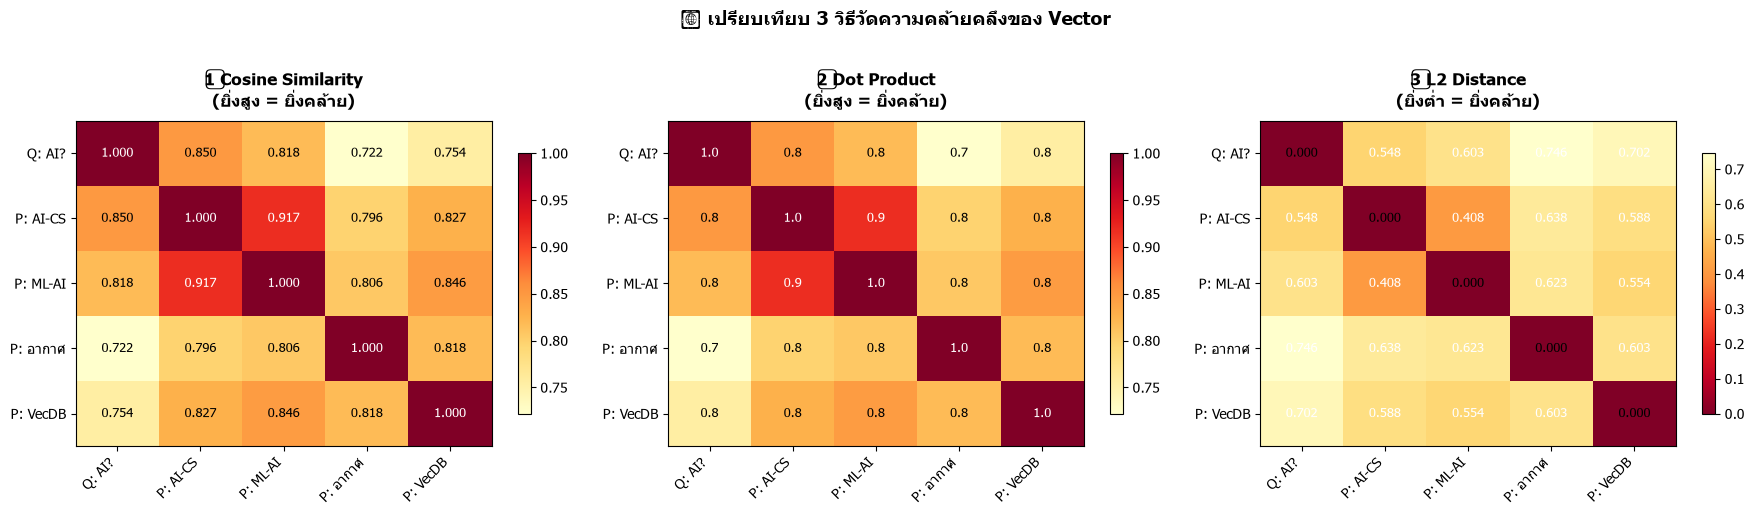


💡 สังเกต:
  - Cosine: ข้อความ AI มี similarity สูง (~0.9), อากาศต่ำ (~0.7)
  - L2: ข้อความ AI มีระยะห่างน้อย, อากาศ มีระยะห่างมาก
  - Dot Product ให้แนวโน้มเดียวกับ Cosine เพราะ vector ถูก normalize แล้ว
CPU times: total: 469 ms
Wall time: 515 ms


In [48]:
%%time
# === วัดความคล้ายคลึง 3 วิธี — แสดงเป็น Heatmap ===
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

labels = ['Q: AI คืออะไร', 'P: AI สาขา CS', 'P: ML ส่วนของ AI', 'P: อากาศดี', 'P: VectorDB']
short_labels = ['Q: AI?', 'P: AI-CS', 'P: ML-AI', 'P: อากาศ', 'P: VecDB']

# คำนวณ 3 วิธี
cos_sim = cosine_similarity(embeddings)
dot_prod = np.dot(embeddings, embeddings.T)
l2_dist = euclidean_distances(embeddings)

# --- Heatmap Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [
    (cos_sim, '1️⃣ Cosine Similarity\n(ยิ่งสูง = ยิ่งคล้าย)', 'YlOrRd', '.3f'),
    (dot_prod, '2️⃣ Dot Product\n(ยิ่งสูง = ยิ่งคล้าย)', 'YlOrRd', '.1f'),
    (l2_dist, '3️⃣ L2 Distance\n(ยิ่งต่ำ = ยิ่งคล้าย)', 'YlOrRd_r', '.3f'),
]

for ax, (matrix, title, cmap, fmt) in zip(axes, matrices):
    im = ax.imshow(matrix, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(short_labels)))
    ax.set_yticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels, fontsize=10, rotation=45, ha='right')
    ax.set_yticklabels(short_labels, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

    # แสดงค่าในแต่ละช่อง
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = matrix[i][j]
            color = 'white' if val > (matrix.max() + matrix.min()) / 2 else 'black'
            ax.text(j, i, f'{val:{fmt}}', ha='center', va='center', fontsize=9, color=color)

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('📐 เปรียบเทียบ 3 วิธีวัดความคล้ายคลึงของ Vector', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 สังเกต:')
print('  - Cosine: ข้อความ AI มี similarity สูง (~0.9), อากาศต่ำ (~0.7)')
print('  - L2: ข้อความ AI มีระยะห่างน้อย, อากาศ มีระยะห่างมาก')
print('  - Dot Product ให้แนวโน้มเดียวกับ Cosine เพราะ vector ถูก normalize แล้ว')

### 🎨 Visualization: ข้อความคล้ายกัน = อยู่ใกล้กัน

ลดมิติจาก 1024 → 2 ด้วย PCA แล้ว plot ดูว่า vector ไหนอยู่ใกล้กัน

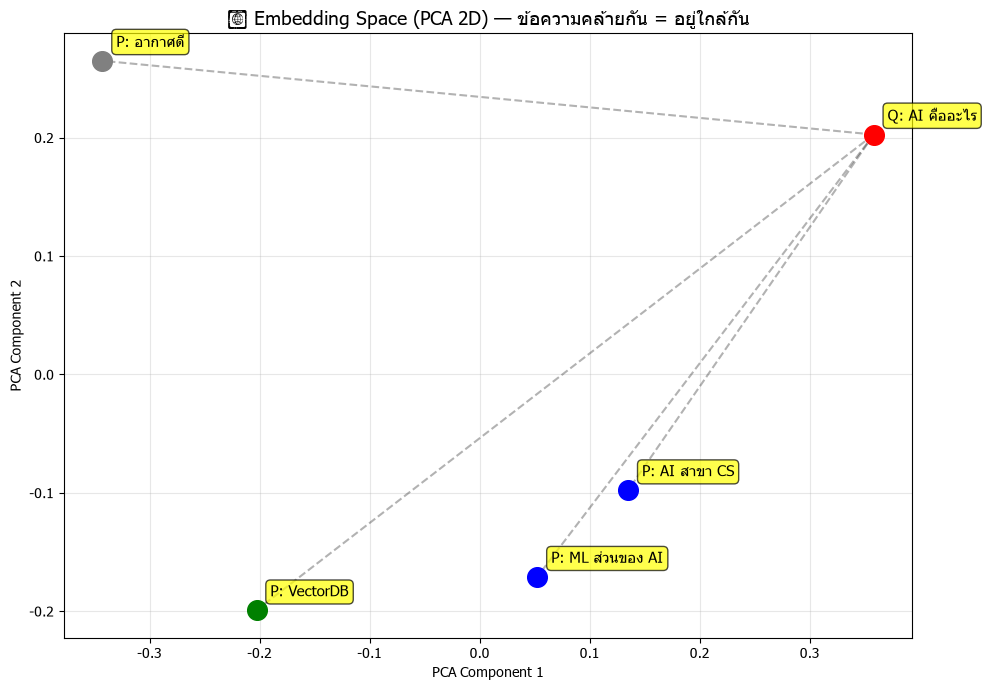

💡 สังเกต: ข้อความเกี่ยวกับ AI (สีน้ำเงิน) อยู่ใกล้กัน
   ส่วนข้อความเรื่องอากาศ (สีเทา) อยู่ไกลออกไป
CPU times: total: 219 ms
Wall time: 448 ms


In [49]:
%%time
from sklearn.decomposition import PCA

# ลดมิติจาก 1024 → 2 ด้วย PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 7))

labels = ['Q: AI คืออะไร', 'P: AI สาขา CS', 'P: ML ส่วนของ AI', 'P: อากาศดี', 'P: VectorDB']
colors = ['red', 'blue', 'blue', 'gray', 'green']

for j, (x, y) in enumerate(coords):
    plt.scatter(x, y, c=colors[j], s=200, zorder=5)
    plt.annotate(labels[j], (x, y), textcoords='offset points',
                 xytext=(10, 10), fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# วาดเส้นจาก query ไปหา passages
for j in range(1, len(coords)):
    plt.plot([coords[0][0], coords[j][0]], [coords[0][1], coords[j][1]],
             'k--', alpha=0.3)

plt.title('📐 Embedding Space (PCA 2D) — ข้อความคล้ายกัน = อยู่ใกล้กัน', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 สังเกต: ข้อความเกี่ยวกับ AI (สีน้ำเงิน) อยู่ใกล้กัน')
print('   ส่วนข้อความเรื่องอากาศ (สีเทา) อยู่ไกลออกไป')

### 💡 สังเกต
- ประโยคที่มี **ความหมายคล้ายกัน** → cosine score **ใกล้ 1.0**
- ประโยคที่ **ไม่เกี่ยวกัน** → cosine score **ใกล้ 0**
- ใน PCA plot: ข้อความเรื่องเดียวกัน **อยู่ใกล้กัน** → นี่คือหลักการของ semantic search
- `multilingual-e5-large` เข้าใจภาษาไทยได้ เพราะ train มากกว่า 100 ภาษา

> 🎯 **Embedding คือแกนหลักของ RAG** — ถ้า embedding แย่ ค้นหาได้ไม่ตรง

### 🧪 แบบฝึกหัด 1.5

ลองสร้างประโยคภาษาไทยของตัวเอง 5 ประโยค แล้วคำนวณ similarity เปรียบเทียบ

In [50]:
%%time
# 🧪 แบบฝึกหัด: ทดลอง embedding กับประโยคภาษาไทยของตัวเอง
# TODO: เขียนโค้ดของคุณที่นี่



CPU times: total: 0 ns
Wall time: 0 ns


---
## 🔀 Section 1.6: Hybrid Embedding (Dense + Sparse)

### Dense Embedding คืออะไร?

**Dense Embedding** คือการแปลงข้อความเป็น vector ที่ **ทุกช่องมีค่า** (ไม่มีค่าเป็น 0)
โดยใช้ Neural Network เรียนรู้ "ความหมาย" ของข้อความ

```
"แมวนอนบนโซฟา" → [0.12, -0.34, 0.56, 0.78, 0.23, -0.11, ...] (1024 ค่า, ทุกค่าไม่เป็น 0)
```

✅ **เก่ง**: เข้าใจ "ความหมาย" — รู้ว่า "หมา" กับ "สุนัข" คือสิ่งเดียวกัน
❌ **อ่อน**: อาจหา keyword เฉพาะไม่เจอ เช่น รหัสสินค้า "SKU-12345"

---

### Sparse Embedding คืออะไร?

**Sparse Embedding** คือการแปลงข้อความเป็น vector ที่ **ส่วนใหญ่เป็น 0**
มีค่าเฉพาะที่ตำแหน่งของคำที่ปรากฏ โดยใช้วิธีทางสถิติ เช่น BM25 หรือ TF-IDF

```
สมมติ vocabulary = [แมว, หมา, นอน, วิ่ง, โซฟา, สวน, ...] (50,000 คำ)

"แมวนอนบนโซฟา" → [0.8, 0, 0.5, 0, 0.3, 0, 0, 0, 0, ...] (50,000 ค่า, ส่วนใหญ่เป็น 0)
                    แมว  หมา นอน วิ่ง โซฟา สวน
```

✅ **เก่ง**: จับ keyword ตรงๆ ได้แม่น เช่น ชื่อเฉพาะ, รหัส, คำศัพท์เทคนิค
❌ **อ่อน**: ไม่เข้าใจ synonym — คิดว่า "หมา" กับ "สุนัข" เป็นคนละคำ

---

### 🔀 Hybrid Search — ทำไมต้องผสม?

| สถานการณ์ | Dense | Sparse | Hybrid |
|-----------|-------|--------|--------|
| "AI คืออะไร" → หา "ปัญญาประดิษฐ์" | ✅ เจอ | ❌ ไม่เจอ | ✅ เจอ |
| หารหัส "SKU-12345" | ❌ ไม่เจอ | ✅ เจอ | ✅ เจอ |
| "วิธีรักษาโรคเบาหวาน" | ✅ เจอ | ✅ เจอ | ✅✅ เจอดีกว่า |

**สูตร Hybrid:**
```
Hybrid Score = α × Dense Score + (1-α) × Sparse Score

α = 1.0 → ใช้ Dense อย่างเดียว
α = 0.5 → ผสมครึ่งครึ่ง (แนะนำ)
α = 0.0 → ใช้ Sparse อย่างเดียว
```

### 🇹🇭 ทำไมภาษาไทยต้องใช้ Tokenizer พิเศษ?

ภาษาไทย **ไม่มีเว้นวรรคระหว่างคำ** ต่างจากภาษาอังกฤษ:

```
English:  "I love machine learning"
          → แค่ split เว้นวรรค → ["I", "love", "machine", "learning"]  ✅ ง่าย!

Thai:     "ฉันรักการเรียนรู้ของเครื่อง"
          → split เว้นวรรค → ["ฉันรักการเรียนรู้ของเครื่อง"]  ❌ ได้คำเดียว!
          → ใช้ pythainlp  → ["ฉัน", "รัก", "การ", "เรียนรู้", "ของ", "เครื่อง"]  ✅
```

**BM25 ต้องการ token (คำ) เพื่อนับความถี่** → ถ้าไม่ตัดคำ จะหาคำไม่เจอ!

เราใช้ `pythainlp.word_tokenize()` ซึ่งใช้ dictionary + ML ตัดคำภาษาไทย

In [51]:
%%time
from rank_bm25 import BM25Okapi
import pythainlp

# เตรียมข้อความสำหรับทดสอบ
documents = [
    'ปัญญาประดิษฐ์ คือสาขาที่สร้างระบบอัจฉริยะ',
    'Machine Learning เป็นส่วนหนึ่งของ AI ที่เรียนรู้จากข้อมูล',
    'NLP ช่วยให้คอมพิวเตอร์เข้าใจภาษามนุษย์',
    'Vector Database เก็บข้อมูลในรูปแบบเวกเตอร์',
    'RAG คือเทคนิครวม LLM กับการค้นหาข้อมูล',
    'Qdrant เป็น open-source vector database',
]

# ตัดคำภาษาไทยด้วย PyThaiNLP
tokenized_docs = [pythainlp.word_tokenize(doc) for doc in documents]
print('📝 ตัวอย่างการตัดคำ:')
for i, (doc, tokens) in enumerate(zip(documents[:2], tokenized_docs[:2])):
    print(f'  [{i}] {doc}')
    print(f'      → {tokens}')

# สร้าง BM25 index (Sparse)
bm25 = BM25Okapi(tokenized_docs)
print(f'\n✅ สร้าง BM25 index สำเร็จ ({len(documents)} documents)')

📝 ตัวอย่างการตัดคำ:
  [0] ปัญญาประดิษฐ์ คือสาขาที่สร้างระบบอัจฉริยะ
      → ['ปัญญาประดิษฐ์', ' ', 'คือ', 'สาขา', 'ที่', 'สร้าง', 'ระบบ', 'อัจฉริยะ']
  [1] Machine Learning เป็นส่วนหนึ่งของ AI ที่เรียนรู้จากข้อมูล
      → ['Machine', ' ', 'Learning', ' ', 'เป็น', 'ส่วนหนึ่ง', 'ของ', ' ', 'AI', ' ', 'ที่', 'เรียนรู้', 'จาก', 'ข้อมูล']

✅ สร้าง BM25 index สำเร็จ (6 documents)
CPU times: total: 438 ms
Wall time: 504 ms


In [52]:
%%time
# ฟังก์ชัน Hybrid Search
def hybrid_search(query, documents, embed_model, bm25, tokenized_docs, alpha=0.5, top_k=3):
    """ค้นหาแบบ Hybrid: ผสม Dense + Sparse"""
    # Dense search (Semantic)
    q_emb = embed_model.encode([f'query: {query}'])
    doc_embs = embed_model.encode([f'passage: {d}' for d in documents])
    dense_scores = cosine_similarity(q_emb, doc_embs)[0]

    # Sparse search (BM25)
    q_tokens = pythainlp.word_tokenize(query)
    sparse_scores = bm25.get_scores(q_tokens)

    # Normalize scores to [0, 1]
    if max(dense_scores) > 0:
        dense_norm = dense_scores / max(dense_scores)
    else:
        dense_norm = dense_scores

    if max(sparse_scores) > 0:
        sparse_norm = sparse_scores / max(sparse_scores)
    else:
        sparse_norm = sparse_scores

    # Hybrid score
    hybrid_scores = alpha * dense_norm + (1 - alpha) * sparse_norm

    # เรียงลำดับ
    ranked = sorted(enumerate(zip(documents, dense_norm, sparse_norm, hybrid_scores)),
                    key=lambda x: x[1][3], reverse=True)
    return ranked[:top_k]

# ทดสอบ
query = 'AI เรียนรู้จากข้อมูล'
results = hybrid_search(query, documents, embed_model, bm25, tokenized_docs, alpha=0.5)

print(f'🔍 Query: "{query}"')
print(f'{"":>4}{"Document":<50} {"Dense":>8} {"Sparse":>8} {"Hybrid":>8}')
print('=' * 82)
for idx, (doc, dense, sparse, hybrid) in results:
    print(f'  [{idx}] {doc:<48} {dense:>8.3f} {sparse:>8.3f} {hybrid:>8.3f}')

🔍 Query: "AI เรียนรู้จากข้อมูล"
    Document                                              Dense   Sparse   Hybrid
  [1] Machine Learning เป็นส่วนหนึ่งของ AI ที่เรียนรู้จากข้อมูล    1.000    1.000    1.000
  [5] Qdrant เป็น open-source vector database             0.919    0.138    0.528
  [3] Vector Database เก็บข้อมูลในรูปแบบเวกเตอร์          0.922    0.110    0.516
CPU times: total: 1.2 s
Wall time: 309 ms


In [53]:
%%time
# เปรียบเทียบ alpha ต่างๆ
print('📊 เปรียบเทียบ alpha (Dense weight) ต่างๆ:')
print('=' * 70)
query = 'vector database สำหรับ RAG'
print(f'Query: "{query}"\n')

for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    results = hybrid_search(query, documents, embed_model, bm25, tokenized_docs, alpha=alpha, top_k=2)
    top_doc = results[0][1][0]
    top_score = results[0][1][3]
    label = 'Sparse only' if alpha == 0 else 'Dense only' if alpha == 1 else f'Hybrid'
    print(f'  α={alpha:.1f} ({label:<12}): [{results[0][0]}] {top_doc[:45]}... ({top_score:.3f})')

📊 เปรียบเทียบ alpha (Dense weight) ต่างๆ:
Query: "vector database สำหรับ RAG"

  α=0.0 (Sparse only ): [5] Qdrant เป็น open-source vector database... (1.000)
  α=0.3 (Hybrid      ): [5] Qdrant เป็น open-source vector database... (0.994)
  α=0.5 (Hybrid      ): [5] Qdrant เป็น open-source vector database... (0.991)
  α=0.7 (Hybrid      ): [5] Qdrant เป็น open-source vector database... (0.987)
  α=1.0 (Dense only  ): [3] Vector Database เก็บข้อมูลในรูปแบบเวกเตอร์... (1.000)
CPU times: total: 5.88 s
Wall time: 1.49 s


### 💡 สังเกต
- **Dense** (embedding) เก่งเรื่อง **ความหมาย** → "รักษาผู้ป่วย" = "ดูแลสุขภาพ"
- **Sparse** (BM25) เก่งเรื่อง **คำตรงตัว** → "Python" หาได้แม่นกว่า
- **alpha=0.7** (Dense 70% + Sparse 30%) มักได้ผลดีสุดกับภาษาไทย
- ภาษาไทยต้องใช้ tokenizer พิเศษ (PyThaiNLP) เพราะไม่มีเว้นวรรค

> 🎯 **Hybrid = ได้ทั้งความหมาย + คำตรงตัว** → แม่นยำกว่าใช้อย่างใดอย่างหนึ่ง

### 🧪 แบบฝึกหัด 1.6

ลองเปลี่ยน query เป็นภาษาไทยล้วนๆ และภาษาอังกฤษล้วนๆ แล้วดูว่า alpha ค่าไหนให้ผลดีที่สุด

In [54]:
%%time
# 🧪 แบบฝึกหัด: ทดลอง Hybrid search กับ query ภาษาไทย

# 💡 Hint:
#   1. ลอง alpha ต่างๆ: 0.0 (Sparse only), 0.5 (50/50), 1.0 (Dense only)
#   2. ลอง query ที่เป็น keyword ตรงๆ vs ความหมาย

# hybrid_search('Deep Learning', all_chunks, embed_model, bm25,
#               tokenized_docs, alpha=0.5, top_k=3)

CPU times: total: 0 ns
Wall time: 0 ns


---
## 🗄️ Section 1.7: ติดตั้ง Qdrant VectorDB

### Vector Database คืออะไร?

**Vector Database** = ฐานข้อมูลที่ออกแบบมาเพื่อเก็บและค้นหา vector ได้เร็ว

```
ข้อความ → Embedding → Vector [0.12, -0.45, 0.78, ...] → เก็บใน VectorDB
                                                           ↕
Query   → Embedding → Vector → ค้นหา vector ที่ใกล้ที่สุด (ANN)
```

### ทำไมเลือก Qdrant?

| VectorDB | ภาษา | Cloud | In-Memory | Open Source |
|----------|------|:-----:|:---------:|:-----------:|
| **Qdrant** | Rust | ✅ | ✅ | ✅ |
| ChromaDB | Python | ❌ | ✅ | ✅ |
| Pinecone | — | ✅ | ❌ | ❌ |
| Weaviate | Go | ✅ | ✅ | ✅ |

> 💡 เราเลือก **Qdrant** เพราะเร็ว (Rust), ใช้ in-memory ได้ (เหมาะ Colab), และ filter ด้วย payload ได้

In [55]:
%%time
from qdrant_client import QdrantClient, models

try:
    qdrant = QdrantClient(':memory:')
    print('✅ เชื่อมต่อ Qdrant สำเร็จ! (in-memory mode)')
    print('💡 in-memory = เก็บใน RAM เร็วแต่ปิด Colab หายหมด')
except Exception as e:
    print(f'❌ ไม่สามารถเชื่อมต่อ Qdrant: {e}')

✅ เชื่อมต่อ Qdrant สำเร็จ! (in-memory mode)
💡 in-memory = เก็บใน RAM เร็วแต่ปิด Colab หายหมด
CPU times: total: 797 ms
Wall time: 956 ms


In [56]:
COLLECTION_NAME = 'thai_documents'
VECTOR_SIZE = 1024

In [57]:
%%time
COLLECTION_NAME = 'thai_documents'
VECTOR_SIZE = 1024

# ตรวจสอบว่า Collection มีอยู่แล้วหรือไม่ ถ้ามีให้ลบออกก่อน
if qdrant.collection_exists(collection_name=COLLECTION_NAME):
    qdrant.delete_collection(collection_name=COLLECTION_NAME)
    print(f'🗑️ ลบ Collection "{COLLECTION_NAME}" ที่มีอยู่แล้ว')

# สร้าง Collection
qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=models.VectorParams(
        size=VECTOR_SIZE,
        distance=models.Distance.COSINE,  # ใช้ Cosine similarity
    ),
)

# ตรวจสอบ
info = qdrant.get_collection(COLLECTION_NAME)
print(f'✅ สร้าง Collection "{COLLECTION_NAME}" สำเร็จ!')
print(f'  Status: {info.status}')
print(f'  Vector size: {info.config.params.vectors.size}')
print(f'  Distance: {info.config.params.vectors.distance}')
print(f'  Points: {info.points_count}')

✅ สร้าง Collection "thai_documents" สำเร็จ!
  Status: green
  Vector size: 1024
  Distance: Cosine
  Points: 0
CPU times: total: 0 ns
Wall time: 0 ns


### 💡 สังเกต
- `:memory:` = เก็บในหน่วยความจำ → เร็ว แต่ปิด Colab แล้วหายหมด
- `Cosine` = เปรียบเทียบ "ทิศทาง" ของ vector → เหมาะกับ NLP
- Production จริง → ใช้ Qdrant Cloud หรือ Docker + persistent storage

> 🎯 VectorDB ทำให้ **ค้นหาจากล้าน vectors ได้ใน milliseconds** ด้วย ANN algorithm

### 🧪 แบบฝึกหัด 1.7

ลองสร้าง collection ใหม่ชื่อ `my_collection` ด้วย distance metric แบบ `EUCLID`

In [58]:
# 🧪 แบบฝึกหัด: สร้าง collection ของตัวเอง
# TODO: เขียนโค้ดของคุณที่นี่



---
## 📥 Section 1.8: สร้าง Index (Upsert ข้อมูล)

### Indexing คืออะไร?

**Indexing** = กระบวนการนำ chunk + embedding + metadata เข้า VectorDB

```
สำหรับแต่ละ chunk:
  1. Embed: แปลง chunk → vector
  2. สร้าง Point: id + vector + payload (text, source)
  3. Upsert: ใส่เข้า Qdrant (ถ้า id ซ้ำจะ update)
```

| คำศัพท์ | ความหมาย |
|--------|----------|
| **Point** | หน่วยข้อมูลใน Qdrant (id + vector + payload) |
| **Payload** | metadata แนบไปกับ vector (text, source, date, ...) |
| **Upsert** | Insert ถ้าใหม่ / Update ถ้ามีอยู่แล้ว |

In [59]:
%%time
# เตรียมข้อมูลสำหรับ indexing
# อ่านเอกสารทั้งหมด → chunk ด้วย recursive splitter

all_chunks = []
for fname in sorted(os.listdir('data')):
    if not fname.endswith('.txt'):
        continue
    with open(f'data/{fname}', 'r', encoding='utf-8') as f:
        text = f.read()

    chunks = recursive_splitter.split_text(text)
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            'text': chunk,
            'source': fname,
            'chunk_index': i,
        })

print(f'📊 เตรียมข้อมูลสำเร็จ:')
print(f'  จำนวน chunks ทั้งหมด: {len(all_chunks)}')
for fname in sorted(os.listdir('data')):
    if fname.endswith('.txt'):
        count = sum(1 for c in all_chunks if c['source'] == fname)
        print(f'  {fname}: {count} chunks')

📊 เตรียมข้อมูลสำเร็จ:
  จำนวน chunks ทั้งหมด: 22
  case_agriculture.txt: 4 chunks
  case_banking.txt: 4 chunks
  case_education.txt: 6 chunks
  case_healthcare.txt: 4 chunks
  case_kmitl.txt: 4 chunks
CPU times: total: 0 ns
Wall time: 2.1 ms


In [60]:
%%time
# สร้าง embeddings สำหรับทุก chunk
print('⏳ กำลังสร้าง embeddings...')
chunk_texts = [f"passage: {c['text']}" for c in all_chunks]
chunk_embeddings = embed_model.encode(chunk_texts, show_progress_bar=True)
print(f'✅ สร้าง embeddings สำเร็จ! ({len(chunk_embeddings)} vectors × {chunk_embeddings.shape[1]} มิติ)')

⏳ กำลังสร้าง embeddings...


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.22s/it]

✅ สร้าง embeddings สำเร็จ! (22 vectors × 1024 มิติ)
CPU times: total: 8.55 s
Wall time: 2.23 s


In [61]:
%%time
# Upsert เข้า Qdrant
points = []
for i, (chunk, embedding) in enumerate(zip(all_chunks, chunk_embeddings)):
    points.append(
        models.PointStruct(
            id=i,
            vector=embedding.tolist(),
            payload={
                'text': chunk['text'],
                'source': chunk['source'],
                'chunk_index': chunk['chunk_index'],
            }
        )
    )

# Upsert ทีเดียว
qdrant.upsert(
    collection_name=COLLECTION_NAME,
    points=points,
)

# ตรวจสอบ
info = qdrant.get_collection(COLLECTION_NAME)
print(f'✅ Upsert สำเร็จ! จำนวน points ใน collection: {info.points_count}')

✅ Upsert สำเร็จ! จำนวน points ใน collection: 22
CPU times: total: 62.5 ms
Wall time: 14.3 ms


### 💡 สังเกต
- **payload** = metadata ที่แนบไปกับ vector (เช่น text, source)
- ช่วยให้ filter ได้ เช่น ค้นเฉพาะ `source='healthcare'`
- **upsert** = insert + update → ถ้า id ซ้ำจะ update แทน

> 🎯 ออกแบบ payload ดี → ค้นหาและ filter ได้ยืดหยุ่นขึ้น

### 🧪 แบบฝึกหัด 1.8

ลองเพิ่มข้อมูลใหม่เข้าไปใน collection (เช่น ข้อความเกี่ยวกับหัวข้อที่สนใจ)

In [62]:
# 🧪 แบบฝึกหัด: เพิ่มข้อมูลของตัวเอง
# TODO: เขียนโค้ดของคุณที่นี่



---
## 🔎 Section 1.9: Retrieve ข้อมูลจาก Qdrant

### Retrieval คืออะไร?

**Retrieval** = ค้นหา chunk ที่เกี่ยวข้องกับ query จาก VectorDB

```
Query: "AI ช่วยหมอยังไง"
  ↓ embed
Vector: [0.23, -0.11, ...]
  ↓ ค้นหาใน Qdrant (Cosine Similarity)
Top-3 Results:
  1. [score=0.92] "โรงพยาบาลศิริราชนำ AI วิเคราะห์ภาพ X-ray..."
  2. [score=0.85] "NLP วิเคราะห์เวชระเบียนอิเล็กทรอนิกส์..."
  3. [score=0.71] "ใช้ Deep Learning ตรวจจับมะเร็ง..."
```

### สิ่งที่ปรับได้

| Parameter | หน้าที่ | ค่าแนะนำ |
|-----------|--------|----------|
| `top_k` | จำนวน chunk ที่ดึง | 3-5 (สมดุลความแม่นยำ/ครอบคลุม) |
| `score_threshold` | ตัดผลที่คะแนนต่ำ | 0.5+ |
| `filter` | กรองด้วย metadata | source, date, category |

### Dense Search (Semantic Search)

### 🎯 top_k คืออะไร?

**`top_k`** คือจำนวนผลลัพธ์ที่ต้องการให้ระบบส่งกลับมา โดยเรียงตาม score จากมากไปน้อย

```
ตัวอย่าง: ถ้ามี 100 chunks ใน database

top_k=3  → ได้ 3 chunks ที่คล้ายที่สุด ✅ เร็ว, บริบทกระชับ
top_k=5  → ได้ 5 chunks ที่คล้ายที่สุด    บริบทมากขึ้น
top_k=10 → ได้ 10 chunks ที่คล้ายที่สุด   ⚠️ อาจมี noise ปนมา
```

**การเลือก top_k ที่เหมาะสม:**

| top_k | เหมาะกับ | ข้อดี | ข้อเสีย |
|-------|---------|-------|--------|
| 1-3 | คำถามเฉพาะเจาะจง | เร็ว, ตรงประเด็น | อาจพลาดข้อมูลสำคัญ |
| 3-5 | คำถามทั่วไป (แนะนำ) | สมดุลดี | — |
| 5-10 | คำถามกว้าง / ซับซ้อน | ครอบคลุม | ช้าขึ้น, context ยาว |

> 💡 **ในทางปฏิบัติ**: top_k=3~5 เป็นค่าที่นิยมใน RAG
> เพราะ LLM ทำงานได้ดีกับบริบทที่กระชับ ไม่ยาวเกินไป

In [63]:
%%time
def search_qdrant(query, top_k=3):
    """ค้นหาข้อมูลจาก Qdrant ด้วย Dense embedding"""
    # สร้าง query embedding
    q_embedding = embed_model.encode([f'query: {query}'])[0]

    # ค้นหา
    results = qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=q_embedding.tolist(),
        limit=top_k,
        with_payload=True,
    )
    return results

# ทดสอบค้นหา
query = 'ปัญญาประดิษฐ์คืออะไร'
results = search_qdrant(query)

print(f'🔍 Query: "{query}"')
print(f'📊 ผลลัพธ์ Top-3:')
print('=' * 70)
for i, point in enumerate(results.points):
    print(f'\n🏆 อันดับ {i+1} (Score: {point.score:.4f})')
    print(f'   แหล่งที่มา: {point.payload["source"]} (chunk {point.payload["chunk_index"]})')
    print(f'   เนื้อหา: {point.payload["text"][:150]}...')

🔍 Query: "ปัญญาประดิษฐ์คืออะไร"
📊 ผลลัพธ์ Top-3:

🏆 อันดับ 1 (Score: 0.7913)
   แหล่งที่มา: case_agriculture.txt (chunk 0)
   เนื้อหา: กรณีศึกษา: AI ในการเกษตรอัจฉริยะ

Smart Farming ในประเทศไทยใช้ AI วิเคราะห์ภาพถ่ายดาวเทียม
และข้อมูลจาก IoT Sensor เพื่อพยากรณ์ผลผลิตและเฝ้าระวังโรคพื...

🏆 อันดับ 2 (Score: 0.7865)
   แหล่งที่มา: case_healthcare.txt (chunk 0)
   เนื้อหา: กรณีศึกษา: AI ในการแพทย์ไทย...

🏆 อันดับ 3 (Score: 0.7850)
   แหล่งที่มา: case_kmitl.txt (chunk 1)
   เนื้อหา: คณะวิศวกรรมศาสตร์ KMITL พัฒนาระบบ AI สำหรับ Smart Campus
ใช้ IoT sensor รวมกับ Machine Learning วิเคราะห์การใช้พลังงานในอาคารเรียน
ผลการทดสอบพบว่าลดค่...
CPU times: total: 297 ms
Wall time: 75.1 ms


### ลองค้นหาคำถามอื่นๆ

In [64]:
%%time
# ทดสอบหลายคำถาม
test_queries = [
    'Vector Database คืออะไร',
    'RAG ทำงานอย่างไร',
    'Deep Learning กับ Machine Learning ต่างกันอย่างไร',
]

for query in test_queries:
    results = search_qdrant(query, top_k=2)
    print(f'\n🔍 Query: "{query}"')
    for i, point in enumerate(results.points):
        print(f'   [{i+1}] (Score: {point.score:.4f}) {point.payload["text"][:80]}...')
    print('-' * 70)


🔍 Query: "Vector Database คืออะไร"
   [1] (Score: 0.8410) เทคโนโลยีที่ใช้: Vector Database สำหรับเก็บ Embedding
Hybrid Search ผสม Dense + ...
   [2] (Score: 0.8151) 4. จัดเก็บ: Upsert Vector เข้า Qdrant หรือ Vector DB อื่น
5. ค้นหา: ใช้ Hybrid S...
----------------------------------------------------------------------

🔍 Query: "RAG ทำงานอย่างไร"
   [1] (Score: 0.8712) ระบบ RAG ทำงานโดยการค้นหาข้อมูลจากฐานความรู้ภายใน
ซึ่งประกอบด้วยเอกสารผลิตภัณฑ์ ...
   [2] (Score: 0.8572) ตัวอย่างที่น่าสนใจคือการใช้ RAG สร้างระบบถาม-ตอบอัตโนมัติ
สำหรับวิชาเรียน โดยนำเ...
----------------------------------------------------------------------

🔍 Query: "Deep Learning กับ Machine Learning ต่างกันอย่างไร"
   [1] (Score: 0.8206) เทคโนโลยีที่ใช้: Vector Database สำหรับเก็บ Embedding
Hybrid Search ผสม Dense + ...
   [2] (Score: 0.8100) 4. จัดเก็บ: Upsert Vector เข้า Qdrant หรือ Vector DB อื่น
5. ค้นหา: ใช้ Hybrid S...
----------------------------------------------------------------------
CPU times: total: 

### ค้นหาพร้อม Filter ด้วย Metadata

In [65]:
%%time
# ค้นหาเฉพาะจากเอกสารที่กำหนด
query = 'การเรียนรู้ของเครื่อง'
q_embedding = embed_model.encode([f'query: {query}'])[0]

results_filtered = qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=q_embedding.tolist(),
    query_filter=models.Filter(
        must=[
            models.FieldCondition(
                key='source',
                match=models.MatchValue(value='case_healthcare.txt'),
            )
        ]
    ),
    limit=3,
    with_payload=True,
)

print(f'🔍 Query: "{query}" (filter: source=case_healthcare.txt)')
for i, point in enumerate(results_filtered.points):
    print(f'   [{i+1}] ({point.score:.4f}) [{point.payload["source"]}] {point.payload["text"][:80]}...')

🔍 Query: "การเรียนรู้ของเครื่อง" (filter: source=case_healthcare.txt)
   [1] (0.7978) [case_healthcare.txt] กรณีศึกษา: AI ในการแพทย์ไทย...
   [2] (0.7856) [case_healthcare.txt] ความท้าทาย: ข้อมูลทางการแพทย์ภาษาไทยมีจำนวนจำกัด
ต้องใช้เทคนิค Transfer Learning...
   [3] (0.7817) [case_healthcare.txt] โรงพยาบาลศิริราชได้นำ AI มาใช้ในการวิเคราะห์ภาพถ่ายทางการแพทย์ (Medical Imaging)...
CPU times: total: 266 ms
Wall time: 73.1 ms


### 💡 สังเกต
- score ใกล้ **1.0** = คล้ายมาก, ใกล้ **0** = ไม่เกี่ยว
- query **ไม่จำเป็นต้องตรงกับ text** เลย → "AI ช่วยหมอ" ก็ค้น "วินิจฉัยโรค" ได้
- `top_k` น้อย (3-5) → ตอบเร็ว แม่นยำ | มาก (10-20) → ครอบคลุม แต่มี noise
- **Filter** ช่วยจำกัดขอบเขตค้นหา → เร็วขึ้น + ตรงประเด็นมากขึ้น

> 🎯 **Retrieval คือขั้นตอนสำคัญที่สุดของ RAG** — ค้นผิด = ตอบผิด

### 🧪 แบบฝึกหัด 1.9

1. ลองค้นหาคำถามภาษาไทยอื่นๆ
2. ลองใช้ filter เพื่อค้นหาเฉพาะจากเอกสารที่ต้องการ
3. ลองเปลี่ยนค่า `top_k` แล้วดูผลลัพธ์ที่ต่างกัน

In [66]:
%%time
# 🧪 แบบฝึกหัด: ทดลองค้นหาจาก Qdrant

# 💡 Hint:
#   1. ลอง query ที่เจาะจง vs กว้างๆ
#   2. ลองปรับ top_k → ผลเปลี่ยนยังไง?
#   3. ลอง filter ด้วย source ต่างๆ

# search_qdrant('ข้าวไทย', top_k=5)
# search_qdrant('AI', top_k=3)  # กว้างเกินไป?

CPU times: total: 0 ns
Wall time: 0 ns


---
## 🚀 Bonus: End-to-End RAG Demo

ลองนำทุกอย่างที่เรียนมาวันนี้มาต่อกัน ส่ง retrieved chunks เข้า Gemini ให้สร้างคำตอบ!

```
คำถาม → Retrieval (Qdrant) → Top Chunks → LLM (Gemini) → คำตอบ
```

> 💡 นี่คือส่วนพรีวิวของ **Day 2** ที่เราจะเรียนรู้การสร้าง Agent เต็มรูปแบบ!

In [67]:
%%time
def rag_answer(question, top_k=3):
    """ระบบ RAG แบบง่าย: ค้นหา + สร้างคำตอบ"""
    # 1. Embed query
    query_vector = embed_model.encode(f'query: {question}').tolist()

    # 2. Retrieve from Qdrant
    results = qdrant.query_points(
        collection_name='thai_documents',
        query=query_vector,
        limit=top_k
    ).points

    # 3. สร้าง context จาก chunks ที่ค้นพบ
    context_parts = []
    print(f'🔍 คำถาม: {question}')
    print(f'📚 Retrieved {len(results)} chunks:')
    for idx, r in enumerate(results):
        text = r.payload['text']
        context_parts.append(text)
        print(f'  [{idx+1}] score={r.score:.4f} | {text[:60]}...')

    context = '\n\n'.join(context_parts)

    # 4. ส่งให้ Gemini สร้างคำตอบ
    prompt = f'''จากบริบทต่อไปนี้ ตอบคำถามเป็นภาษาไทย กระชับ ชัดเจน
ถ้าไม่มีข้อมูลเพียงพอให้บอกว่า "ข้อมูลไม่เพียงพอ"

บริบท:
{context}

คำถาม: {question}
คำตอบ:'''

    response = client.models.generate_content(
        # model='gemini-2.5-flash',
        model='gemini-3.1-flash-lite',
        contents=prompt
    )

    print(f'\n🤖 คำตอบจาก RAG:')
    print(f'   {response.text.strip()}')
    print()
    return response.text.strip()

# ทดสอบกับหลายคำถาม
questions = [
    'AI ช่วยในวงการแพทย์ไทยอย่างไร',
    'RAG ใช้ในธนาคารอย่างไร',
    'ขั้นตอนสร้างระบบ AI ช่วยสอนมีอะไรบ้าง',
    'มหาวิทยาลัยใช้ AI อย่างไรได้บ้าง'
]

for q in questions:
    print('=' * 60)
    rag_answer(q)
    print()

🔍 คำถาม: AI ช่วยในวงการแพทย์ไทยอย่างไร
📚 Retrieved 3 chunks:
  [1] score=0.8733 | โรงพยาบาลศิริราชได้นำ AI มาใช้ในการวิเคราะห์ภาพถ่ายทางการแพท...
  [2] score=0.8680 | กรณีศึกษา: AI ในการแพทย์ไทย...
  [3] score=0.8512 | กรณีศึกษา: AI ในการศึกษาไทย

มหาวิทยาลัยหลายแห่งในไทยเริ่มนำ...

🤖 คำตอบจาก RAG:
   ช่วยในการวิเคราะห์ภาพถ่ายทางการแพทย์ เช่น การตรวจจับมะเร็งปอดจากภาพ X-ray ด้วยเทคโนโลยี Deep Learning ซึ่งมีความแม่นยำสูงถึง 95%


🔍 คำถาม: RAG ใช้ในธนาคารอย่างไร
📚 Retrieved 3 chunks:
  [1] score=0.8503 | กรณีศึกษา: AI ในธนาคารและการเงิน

ธนาคารกสิกรไทยได้พัฒนาระบบ...
  [2] score=0.8480 | ตัวอย่างที่น่าสนใจคือการใช้ RAG สร้างระบบถาม-ตอบอัตโนมัติ
สำ...
  [3] score=0.8456 | ระบบ RAG ทำงานโดยการค้นหาข้อมูลจากฐานความรู้ภายใน
ซึ่งประกอบ...

🤖 คำตอบจาก RAG:
   คำตอบ: RAG ใช้ในการสร้างระบบถาม-ตอบอัตโนมัติ เพื่อตอบคำถามลูกค้าเกี่ยวกับผลิตภัณฑ์ เงื่อนไขบริการ และ FAQ โดยดึงข้อมูลจากฐานความรู้ภายในมาให้ LLM สร้างคำตอบที่ถูกต้องและเป็นธรรมชาติ


🔍 คำถาม: ขั้นตอนสร้างระบบ AI ช่วยสอนมีอะไรบ้าง
📚 Retr

---
## 🎯 สรุป: สิ่งที่เราเรียนรู้ในวันนี้

### Pipeline ทั้งหมดของ Data Engineering สำหรับ RAG

| Step | Section | Task |
|:----:|---------|------|
| 📄 | Input | Raw Documents (PDF, TXT, DOCX) |
| 🔍 | 1.1 | ตรวจ Duplicate (MD5) → ลบไฟล์ซ้ำ |
| 📝 | 1.3-1.4 | แปลง Markdown (Gemini / Docling) |
| ✂️ | 1.2 | Chunking (Fixed / Recursive / Sentence) |
| 🔢 | 1.5 | Dense Embedding (multilingual-e5-large) |
| 🔀 | 1.6 | Hybrid Embedding (Dense + BM25) |
| 🗄️ | 1.7 | สร้าง Qdrant Collection |
| 📥 | 1.8 | Index (Upsert vectors + metadata) |
| 🔎 | 1.9 | Retrieve (Dense / Filtered search) |


### 🔑 Key Takeaways

1. **คุณภาพข้อมูลสำคัญที่สุด** — "Garbage in, garbage out"
2. **Chunking strategy** มีผลมากต่อคุณภาพ RAG
3. **Hybrid search** (Dense + Sparse) มักดีกว่าใช้อย่างใดอย่างหนึ่ง
4. **Metadata** ช่วยให้ filter ผลลัพธ์ได้แม่นยำขึ้น

### 📅 ครั้งหน้า: Day 2 — Building Agents: Finding the Needle in the Haystack

เราจะเรียนรู้วิธีสร้าง **AI Agents** ที่ใช้ RAG pipeline ที่สร้างไว้
ในการตอบคำถามอย่างชาญฉลาด!